# Dataset Generation

We need training data with known quality issues, but there is no large-scale dataset with
per-image quality labels for the specific issues we want to detect (blur, noise, exposure, etc.).
So we generate our own by starting from clean images and applying controlled degradations.

Using Places365 validation set as clean sources because:
- Diverse indoor/outdoor scenes (not just faces or objects)
- Already resized to 256px, manageable size
- Publicly available, easy to reproduce

Key design decision: we split the clean images into train/val/test **before** applying
any degradations. This way no version of the same image leaks across splits.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from config import *

print(f"Source images: {DATASET_SIZE}")
print(f"Seed: {RANDOM_SEED}")
print(f"Splits: {TRAIN_RATIO}/{VAL_RATIO}/{TEST_RATIO}")
print(f"Image size: {IMG_SIZE}")

Source images: 5000
Seed: 42
Splits: 0.7/0.15/0.15
Image size: 128


## Check source images

In [2]:
from pathlib import Path

all_images = sorted(PLACES365_RAW_DIR.glob("**/*.jpg"))
print(f"Found {len(all_images)} images in {PLACES365_RAW_DIR}")
print(f"Examples: {[p.name for p in all_images[:3]]}")

Found 36500 images in S:\IIIT Hydrabad\data\places365_raw
Examples: ['Places365_val_00000001.jpg', 'Places365_val_00000002.jpg', 'Places365_val_00000003.jpg']


## Generate dataset

Splits clean images first (no leakage), then applies degradations per split.

In [3]:
from ml.synthetic_data import build_dataset

save_dir = DATA_DIR / "generated"

dataset = build_dataset(
    source_dir=PLACES365_RAW_DIR,
    max_source_images=DATASET_SIZE,
    img_size=IMG_SIZE,
    seed=RANDOM_SEED,
    save_dir=save_dir,
)

for split, samples in dataset.items():
    print(f"{split}: {len(samples)} samples")
print(f"Total: {sum(len(v) for v in dataset.values())}")

Finding source images in S:\IIIT Hydrabad\data\places365_raw...
Found 5000 source images
Splitting source images into train/val/test...
  train: 3500 sources
  val: 750 sources
  test: 750 sources
  [train] 500/3500 (6079 samples)
  [train] 1000/3500 (12171 samples)
  [train] 1500/3500 (18290 samples)
  [train] 2000/3500 (24415 samples)
  [train] 2500/3500 (30525 samples)
  [train] 3000/3500 (36606 samples)
  [train] 3500/3500 (42721 samples)
  [train] done: 42721 samples
  [val] 500/750 (6110 samples)
  [val] done: 9151 samples
  [test] 500/750 (6107 samples)
  [test] done: 9145 samples
  Saved 42721 to S:\IIIT Hydrabad\data\generated\train\images
  Saved 9151 to S:\IIIT Hydrabad\data\generated\val\images
  Saved 9145 to S:\IIIT Hydrabad\data\generated\test\images
train: 42721 samples
val: 9151 samples
test: 9145 samples
Total: 61017


## Verify no data leakage

In [4]:
import pandas as pd

train_meta = pd.read_csv(save_dir / "train" / "metadata.csv")
val_meta = pd.read_csv(save_dir / "val" / "metadata.csv")
test_meta = pd.read_csv(save_dir / "test" / "metadata.csv")

# extract base image name from source_image_id
get_base = lambda df: set(df['source_image_id'].str.split('_', n=2).str[2])
train_src, val_src, test_src = get_base(train_meta), get_base(val_meta), get_base(test_meta)

print(f"Train âˆ© Val:  {len(train_src & val_src)} (expect 0)")
print(f"Train âˆ© Test: {len(train_src & test_src)} (expect 0)")
print(f"Val âˆ© Test:   {len(val_src & test_src)} (expect 0)")
assert not (train_src & val_src) and not (train_src & test_src) and not (val_src & test_src)
print("No leakage âœ“")

Train âˆ© Val:  0 (expect 0)
Train âˆ© Test: 0 (expect 0)
Val âˆ© Test:   0 (expect 0)
No leakage âœ“


## Distribution plots

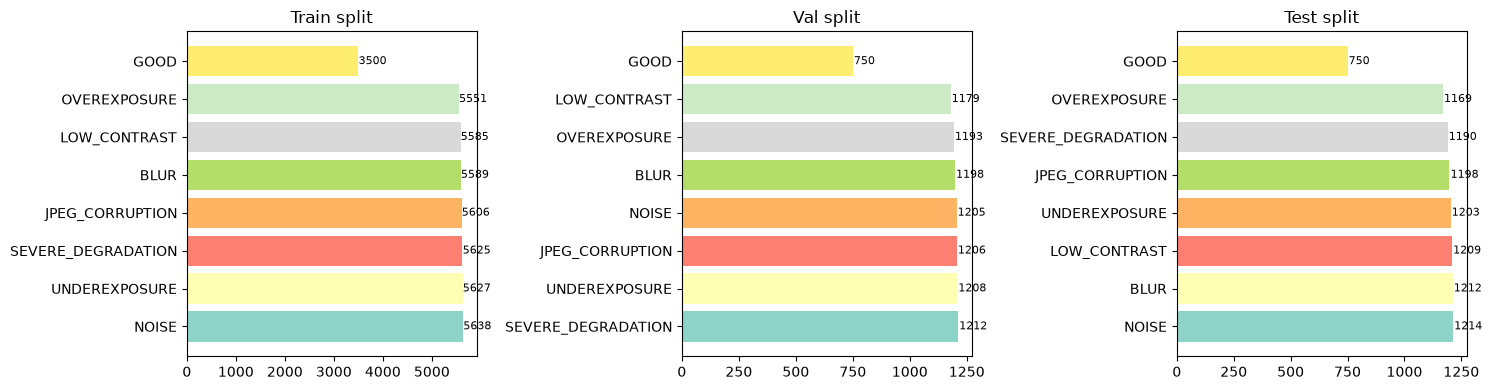

In [5]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, meta) in zip(axes, [("Train", train_meta), ("Val", val_meta), ("Test", test_meta)]):
    counts = meta['degradation_type'].value_counts()
    ax.barh(counts.index, counts.values, color=plt.cm.Set3(np.linspace(0, 1, len(counts))))
    ax.set_title(f'{name} split')
    for i, v in enumerate(counts.values):
        ax.text(v + 5, i, str(v), va='center', fontsize=8)
plt.tight_layout()
plt.savefig(str(save_dir / "degradation_distribution.png"), dpi=150, bbox_inches='tight')
plt.show()

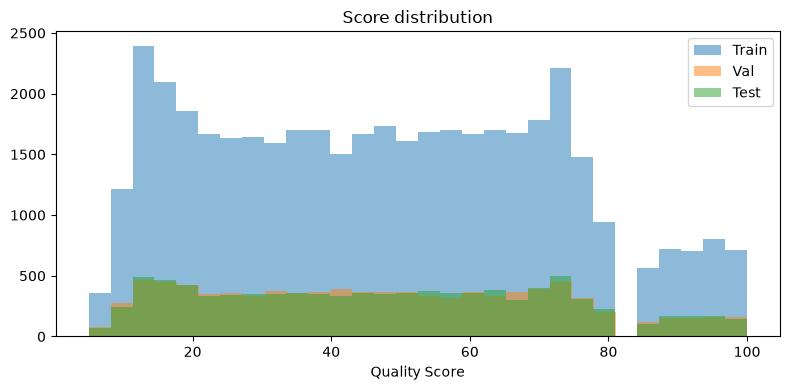

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
for name, meta in [("Train", train_meta), ("Val", val_meta), ("Test", test_meta)]:
    ax.hist(meta['quality_score'], bins=30, alpha=0.5, label=name)
ax.set_xlabel('Quality Score')
ax.legend()
ax.set_title('Score distribution')
plt.tight_layout()
plt.savefig(str(save_dir / "quality_score_distribution.png"), dpi=150, bbox_inches='tight')
plt.show()

## Sample degradations

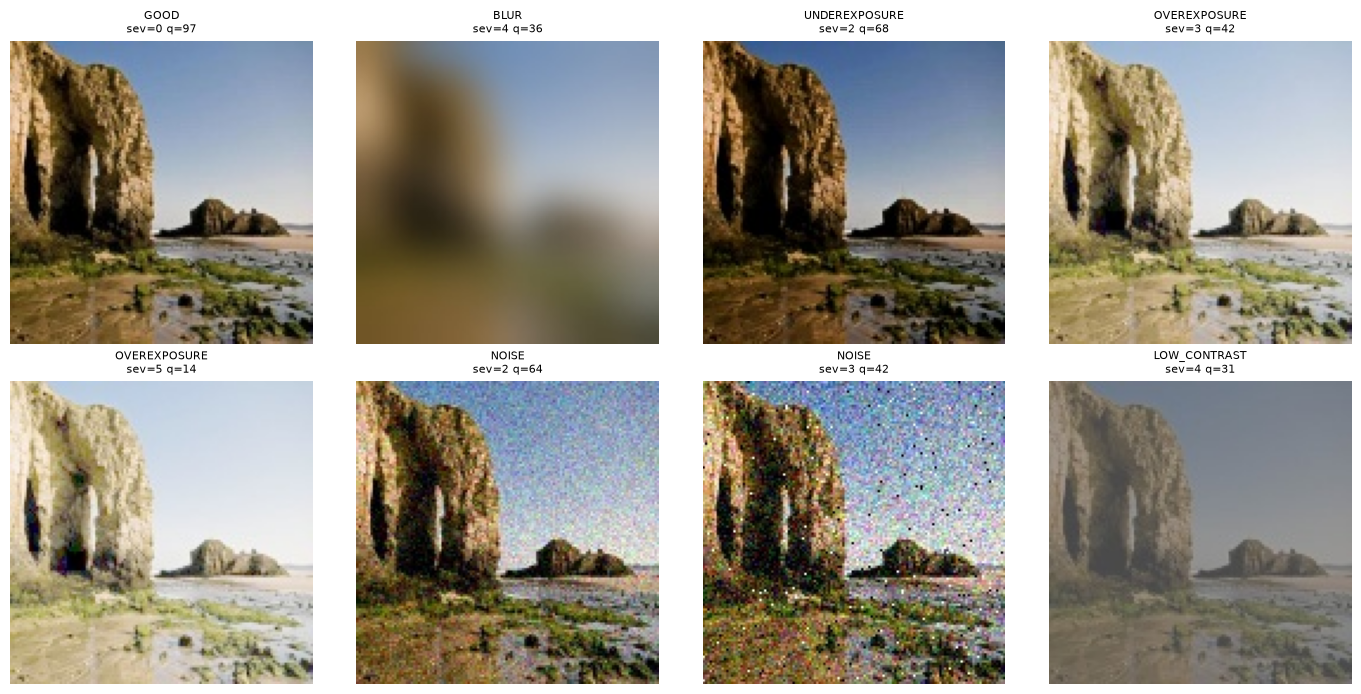

In [7]:
import cv2

source = train_meta['source_image_id'].unique()[0]
rows = train_meta[train_meta['source_image_id'] == source]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for idx, (_, row) in enumerate(rows.iterrows()):
    if idx >= 8: break
    img = cv2.cvtColor(cv2.imread(str(save_dir / "train" / "images" / row['filename'])), cv2.COLOR_BGR2RGB)
    ax = axes[idx // 4][idx % 4]
    ax.imshow(img)
    ax.set_title(f"{row['degradation_type']}\nsev={row['severity']} q={row['quality_score']:.0f}", fontsize=8)
    ax.axis('off')
for ax in axes.flatten()[len(rows):]: ax.axis('off')
plt.tight_layout()
plt.savefig(str(save_dir / "sample_degradations.png"), dpi=150, bbox_inches='tight')
plt.show()